In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import h5py
import numpy as np
import timm
import random
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [15]:
# ============================================
# UPDATED HDF5 DATASET + DATALOADER (FINAL)
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import h5py, numpy as np, torch, random
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF

TRAIN_H5 = "/content/drive/MyDrive/morph_project/processed/train.h5"
TEST_H5  = "/content/drive/MyDrive/morph_project/processed/test.h5"
IMG_SIZE = 224


class H5Dataset(Dataset):
    def __init__(self, h5_path, train=False):
        self.h5 = h5py.File(h5_path, "r")
        self.X = self.h5["X"]    # standardized float32 images
        self.y = self.h5["y"]
        self.train = train

        # Light, ViT-friendly augmentations
        self.color_jitter = T.ColorJitter(
            brightness=0.10, contrast=0.10, saturation=0.10
        )

        self.erasing = T.RandomErasing(
            p=0.10, scale=(0.02, 0.10), ratio=(0.3, 3.3)
        )

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        img = self.X[idx]              # HWC float32
        label = int(self.y[idx])

        img_t = torch.from_numpy(img).permute(2,0,1).float()

        # -------------------------
        # Light & Stable ViT Augmentation
        # -------------------------
        if self.train:

            # Horizontal Flip
            if random.random() < 0.5:
                img_t = torch.flip(img_t, dims=[2])

            # Very mild rotation
            if random.random() < 0.15:
                angle = random.uniform(-5, 5)
                img_t = TF.rotate(img_t, angle)

            # Mild Color Jitter
            if random.random() < 0.15:
                img_t = self.color_jitter(img_t)

            # VERY light Random Erasing
            if random.random() < 0.10:
                img_t = self.erasing(img_t)

        return img_t, torch.tensor(label, dtype=torch.long)



# ======================================================
# Instantiate Datasets + Weighted Sampler + DataLoaders
# ======================================================

train_ds = H5Dataset(TRAIN_H5, train=True)
test_ds  = H5Dataset(TEST_H5,  train=False)

print("Dataset sizes — train:", len(train_ds), " test:", len(test_ds))


# Weighted Sampler for Class Imbalance
train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)
print("Class Counts:", class_counts)

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


# Final Tuned Dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=16,       # Best size for ViT
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset sizes — train: 7177  test: 1803
Class Counts: [5946 1231]
Train batches: 449
Val batches: 113


In [16]:
train_labels = np.array(train_ds.h5["y"][:])
class_counts = np.bincount(train_labels)
print("Class counts:", class_counts)

# class weights for sampler
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# BEST batch size = 16
train_loader = DataLoader(
    train_ds, batch_size=16, sampler=sampler, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    test_ds, batch_size=16, shuffle=False, num_workers=2, pin_memory=True
)

print("Train batches:", len(train_loader), "Val batches:", len(val_loader))


Class counts: [5946 1231]
Train batches: 449 Val batches: 113


In [18]:
import timm

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
).to(device)

print("ViT model created.")

# class weights for cross entropy
count_au, count_tp = class_counts[0], class_counts[1]
total = count_au + count_tp

w_au = total / (2 * count_au)
w_tp = total / (2 * count_tp)

weights = torch.tensor([w_au, w_tp], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# Best optimizer hyperparameters
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,        # or 5e-5 as we tested
    weight_decay=1e-5
)


# BEST SCHEDULER — warmup + cosine annealing
from transformers import get_cosine_schedule_with_warmup

epochs = 15
total_steps = len(train_loader) * epochs
warmup_steps = int(0.06 * total_steps)    # 6% warmup → smoother ViT start

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# AMP scaler
from torch.cuda.amp import GradScaler, autocast
scaler = GradScaler()


ViT model created.


/tmp/ipython-input-4228543356.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [19]:
import time
from torch.amp.autocast_mode import autocast

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
save_path = "/content/drive/MyDrive/morph_project/models/vit_tuned.pth"


def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [20]:
for epoch in range(1, epochs+1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = validate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc*100:.2f}%")
    print(f"Time: {time.time()-t0:.1f} sec")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"🔥 Saved BEST model (Val Acc: {val_acc*100:.2f}%)")

print("\nTraining complete!")
print("Best Validation Accuracy:", best_val_acc * 100, "%")



Epoch 1/15
Train Loss: 0.8799 | Train Acc: 51.12%
Val   Loss: 0.8388 | Val   Acc: 50.47%
Time: 120.2 sec
🔥 Saved BEST model (Val Acc: 50.47%)

Epoch 2/15
Train Loss: 0.6347 | Train Acc: 52.31%
Val   Loss: 1.5192 | Val   Acc: 25.07%
Time: 102.8 sec

Epoch 3/15
Train Loss: 0.5195 | Train Acc: 51.85%
Val   Loss: 1.5259 | Val   Acc: 23.18%
Time: 101.2 sec

Epoch 4/15
Train Loss: 0.4707 | Train Acc: 53.46%
Val   Loss: 1.4152 | Val   Acc: 24.40%
Time: 100.8 sec

Epoch 5/15
Train Loss: 0.4445 | Train Acc: 53.99%
Val   Loss: 1.3097 | Val   Acc: 27.40%
Time: 101.4 sec

Epoch 6/15
Train Loss: 0.4059 | Train Acc: 56.79%
Val   Loss: 1.1515 | Val   Acc: 32.56%
Time: 100.1 sec

Epoch 7/15
Train Loss: 0.3704 | Train Acc: 61.61%
Val   Loss: 1.0695 | Val   Acc: 39.77%
Time: 101.2 sec

Epoch 8/15
Train Loss: 0.3245 | Train Acc: 67.59%
Val   Loss: 0.9584 | Val   Acc: 47.75%
Time: 101.3 sec

Epoch 9/15
Train Loss: 0.2815 | Train Acc: 73.71%
Val   Loss: 0.7511 | Val   Acc: 61.73%
Time: 100.7 sec
🔥 Saved B

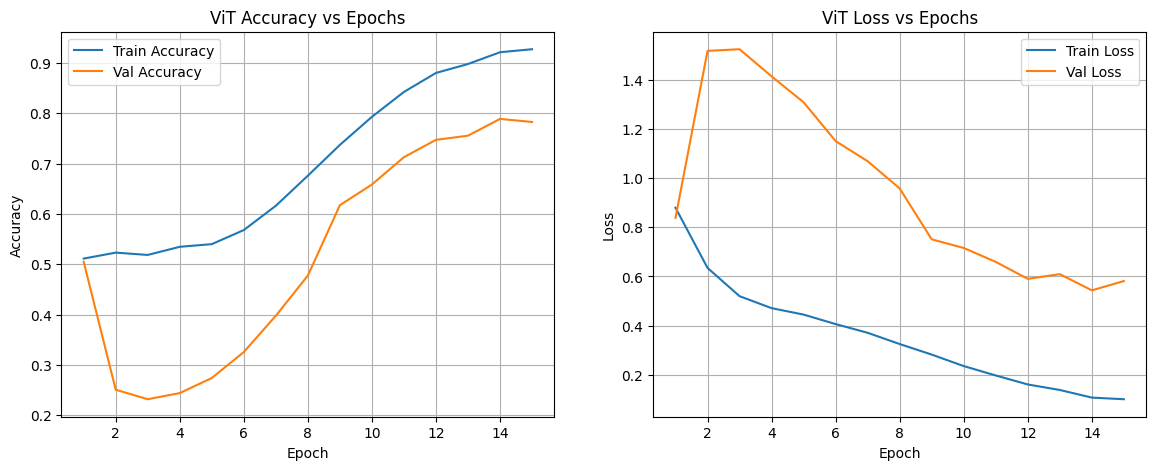

In [21]:
# ============================================
# VIT — TRAINING METRICS: ACCURACY & LOSS PLOTS
# ============================================

import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,5))

# ----------- ACCURACY PLOT -------------
plt.subplot(1,2,1)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Accuracy vs Epochs")
plt.legend()
plt.grid(True)

# ----------- LOSS PLOT -----------------
plt.subplot(1,2,2)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Loss vs Epochs")
plt.legend()
plt.grid(True)

plt.show()


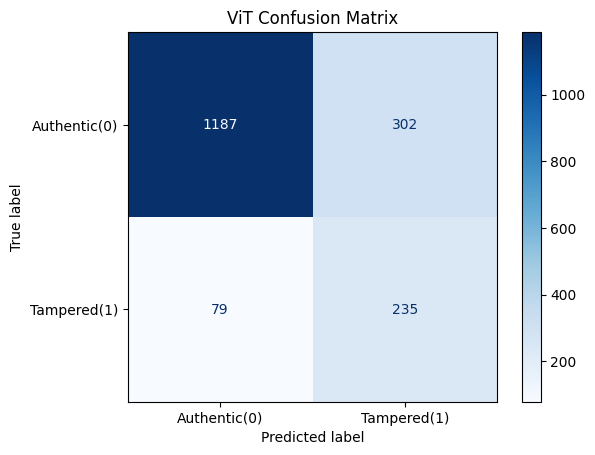

In [22]:
# =========================================
# VIT — CONFUSION MATRIX
# =========================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic(0)", "Tampered(1)"])
disp.plot(cmap="Blues")
plt.title("ViT Confusion Matrix")
plt.show()


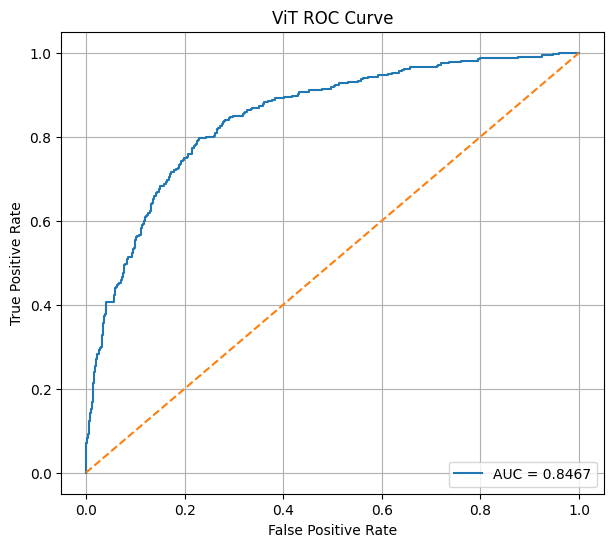

In [23]:
# =========================================
# VIT — ROC CURVE & AUC
# =========================================

from sklearn.metrics import roc_curve, auc

model.eval()
y_true = []
y_score = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        y_score.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [26]:
# ================================
# VI T  --  FINAL INFERENCE CELL
# ================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import timm
import cv2
import numpy as np
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# -------------------------
# Universal Preprocessing
# -------------------------

MEAN = -2.6647588e-06
STD  = 0.9996273

def preprocess_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (224, 224))

    # Denoise
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)

    # Histogram Equalization
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    # Sharpen
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    img = cv2.filter2D(img, -1, kernel)

    img = img.astype(np.float32) / 255.0
    img = (img - MEAN) / (STD + 1e-7)

    img = torch.tensor(img).permute(2,0,1).float().unsqueeze(0)
    return img.to(device)


# -------------------------
# Load ViT Model
# -------------------------

model_path = "/content/drive/MyDrive/morph_project/models/vit_tuned.pth"

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=False,
    num_classes=2
)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✅ ViT Model Loaded Successfully!")


# -------------------------
# Prediction Function
# -------------------------

def predict_image(path):
    img = preprocess_image(path)

    with torch.no_grad():
        out = model(img)
        probs = torch.softmax(out, dim=1)[0]

    pred = probs.argmax().item()
    confidence = float(probs[pred] * 100)

    label = "Authentic (AU, 0)" if pred == 0 else "Tampered (TP, 1)"

    print("\n===========================")
    print(f"IMAGE: {path}")
    print(f"PREDICTION: {label}")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print("===========================\n")


# -------------------------
# Upload & Predict
# -------------------------

uploaded = files.upload()
for name in uploaded.keys():
    predict_image(name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
✅ ViT Model Loaded Successfully!


Saving img0.1.png to img0.1.png

IMAGE: img0.1.png
PREDICTION: Tampered (TP, 1)
CONFIDENCE: 59.10%



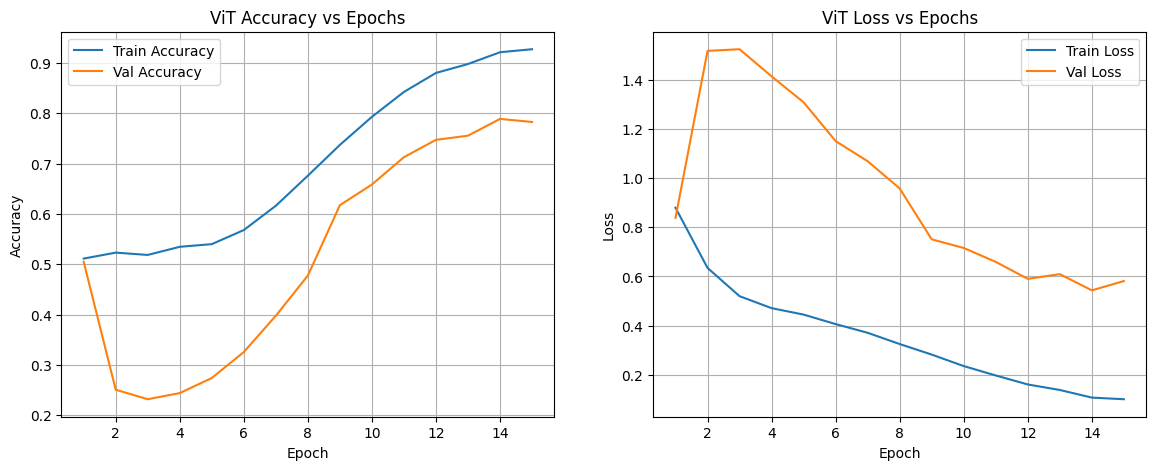

<Figure size 600x600 with 0 Axes>

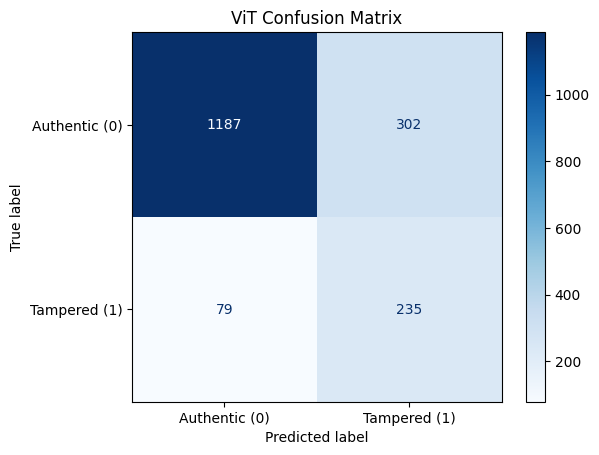

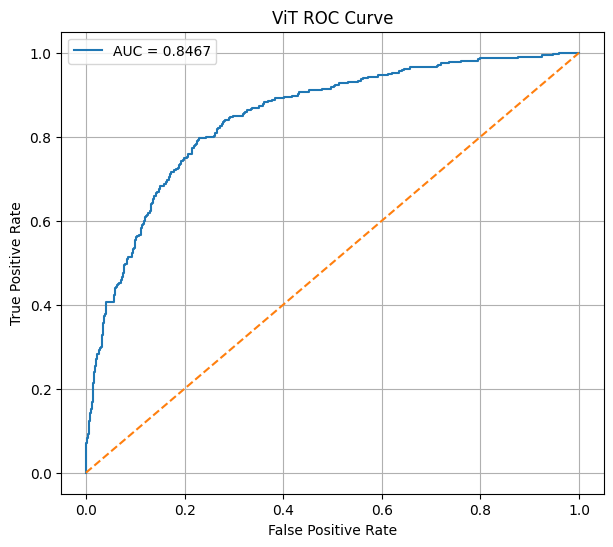

In [27]:
# =======================================================
# 1. ACCURACY vs EPOCHS & LOSS vs EPOCHS
# =======================================================

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Accuracy vs Epochs")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Loss vs Epochs")
plt.legend()
plt.grid(True)

plt.show()


# =======================================================
# 2. CONFUSION MATRIX
# =======================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Authentic (0)", "Tampered (1)"]
)
plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("ViT Confusion Matrix")
plt.show()


# =======================================================
# 3. ROC CURVE + AUC
# =======================================================

from sklearn.metrics import roc_curve, auc

y_true = []
y_scores = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)

        probs = torch.softmax(outputs, dim=1)[:, 1]

        y_scores.extend(probs.cpu().numpy())
        y_true.extend(labels.numpy())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT ROC Curve")
plt.grid(True)
plt.legend()
plt.show()
